In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns
import warnings


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

import warnings
# Set the warning filter to ignore FutureWarning
warnings.simplefilter(action = "ignore", category = FutureWarning)


# Carreguem el dataset
df = pd.read_csv('injury_data.csv')

# Mostrem les primeres files per familiaritzar-nos amb les dades
print(df.head())

# Suposem que la columna objectiu és 'injury' (1 = lesionat, 0 = no lesionat)
target = 'Likelihood_of_Injury'

# Separem les característiques (features) de la variable objectiu (target)
X = df.drop(target, axis=1)
y = df[target]

   Player_Age  Player_Weight  Player_Height  Previous_Injuries  \
0          24      66.251933     175.732429                  1   
1          37      70.996271     174.581650                  0   
2          32      80.093781     186.329618                  0   
3          28      87.473271     175.504240                  1   
4          25      84.659220     190.175012                  0   

   Training_Intensity  Recovery_Time  Likelihood_of_Injury  
0            0.457929              5                     0  
1            0.226522              6                     1  
2            0.613970              2                     1  
3            0.252858              4                     1  
4            0.577632              1                     1  


In [62]:
from sklearn import preprocessing
X_estandard= preprocessing.StandardScaler().fit(X)
X_estandard = X_estandard.fit_transform(X)


In [63]:
x_train, x_test, y_train, y_test = train_test_split(X_estandard, y, test_size = .10, random_state = 101)

In [64]:
# Fit
# Import model
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create instance of model
lin_reg = LinearRegression()

# Pass training data into model
lin_reg.fit(x_train, y_train)
pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [65]:
# Predict del test
y_pred = lin_reg.predict(x_test)
print(y_pred)

[0.46833967 0.55763671 0.56186167 0.54092527 0.43485218 0.52221289
 0.467164   0.4543322  0.40701473 0.5288165  0.57865229 0.51262747
 0.52247617 0.48396879 0.55439232 0.46880327 0.50652231 0.52552082
 0.50040387 0.53102135 0.44245573 0.53094948 0.49196016 0.6018452
 0.47249079 0.57017172 0.43324612 0.56272753 0.48295569 0.56117276
 0.47536973 0.53004958 0.50961034 0.45007779 0.41140414 0.58733859
 0.5153536  0.49406553 0.5046166  0.48057972 0.53066849 0.49029609
 0.46018305 0.481668   0.49137757 0.39022618 0.42545586 0.54759306
 0.47387912 0.50236409 0.49683043 0.47496231 0.55138802 0.49801128
 0.56622047 0.45031603 0.49605676 0.52667441 0.40545149 0.47968691
 0.45206136 0.53944651 0.55576534 0.43177899 0.49128461 0.4775476
 0.50206723 0.46128786 0.52819227 0.45054745 0.52468717 0.54213063
 0.53668196 0.49591626 0.54058507 0.48771379 0.43535025 0.50084598
 0.51509586 0.55429709 0.47826545 0.49541493 0.51543125 0.46544636
 0.45456473 0.46171752 0.47277704 0.49225644 0.45693056 0.474223

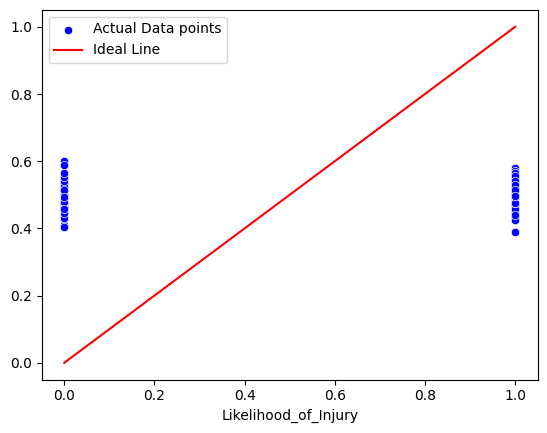

In [66]:
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Actual Data points')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Ideal Line')
plt.legend()
plt.show()

In [67]:
# Combine actual and predicted values side by side
results = np.column_stack((y_test, y_pred))

# Printing the results
print("Actual Values  |  Predicted Values")
print("-----------------------------")
for actual, predicted in results:
    print(f"{actual:14.2f} |  {predicted:12.2f}")

Actual Values  |  Predicted Values
-----------------------------
          0.00 |          0.47
          1.00 |          0.56
          0.00 |          0.56
          1.00 |          0.54
          1.00 |          0.43
          0.00 |          0.52
          0.00 |          0.47
          1.00 |          0.45
          0.00 |          0.41
          0.00 |          0.53
          1.00 |          0.58
          1.00 |          0.51
          1.00 |          0.52
          1.00 |          0.48
          0.00 |          0.55
          1.00 |          0.47
          1.00 |          0.51
          1.00 |          0.53
          0.00 |          0.50
          0.00 |          0.53
          1.00 |          0.44
          1.00 |          0.53
          1.00 |          0.49
          0.00 |          0.60
          1.00 |          0.47
          1.00 |          0.57
          0.00 |          0.43
          0.00 |          0.56
          0.00 |          0.48
          1.00 |          0.56
     

In [68]:
residual = actual- y_pred.reshape(-1)
print(residual)

[0.53166033 0.44236329 0.43813833 0.45907473 0.56514782 0.47778711
 0.532836   0.5456678  0.59298527 0.4711835  0.42134771 0.48737253
 0.47752383 0.51603121 0.44560768 0.53119673 0.49347769 0.47447918
 0.49959613 0.46897865 0.55754427 0.46905052 0.50803984 0.3981548
 0.52750921 0.42982828 0.56675388 0.43727247 0.51704431 0.43882724
 0.52463027 0.46995042 0.49038966 0.54992221 0.58859586 0.41266141
 0.4846464  0.50593447 0.4953834  0.51942028 0.46933151 0.50970391
 0.53981695 0.518332   0.50862243 0.60977382 0.57454414 0.45240694
 0.52612088 0.49763591 0.50316957 0.52503769 0.44861198 0.50198872
 0.43377953 0.54968397 0.50394324 0.47332559 0.59454851 0.52031309
 0.54793864 0.46055349 0.44423466 0.56822101 0.50871539 0.5224524
 0.49793277 0.53871214 0.47180773 0.54945255 0.47531283 0.45786937
 0.46331804 0.50408374 0.45941493 0.51228621 0.56464975 0.49915402
 0.48490414 0.44570291 0.52173455 0.50458507 0.48456875 0.53455364
 0.54543527 0.53828248 0.52722296 0.50774356 0.54306944 0.525776

C:\Users\roger\AppData\Local\Temp\ipykernel_11416\1387356995.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, kde=True)


<Axes: ylabel='Density'>

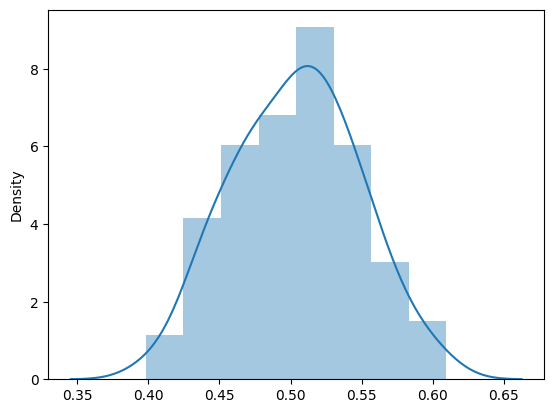

In [69]:
# Distribution plot for Residual (difference between actual and predicted values)
sns.distplot(residual, kde=True)

In [70]:
# Score It
from sklearn.metrics import mean_squared_error

print('Linear Regression Model')
# Results
print('--'*30)
# mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print evaluation metrics
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Linear Regression Model
------------------------------------------------------------
Mean Squared Error: 0.25194981513594983
Root Mean Squared Error: 0.5019460281105428
